# read_wholeday_v1.ipynb — Whole-day Type III Burst Count

Reads the full CD file, computes sunrise/sunset for Tremsdorf via astropy, applies a **daytime-only mask**, then loops over all 24 hours counting grouped Hough lines as bursts.



| Step | drb function |
|------|-------------|
| Load | `drb.read_osraf2()` |
| Preprocess (once, global) | `drb.preproc2()` |
| Binarize | `drb.binarization()` |
| Hough detect | `drb.hough_detect()` |
| Group lines | `drb.line_grouping()` (empty-safe edit already in drb) |

> **v1 behaviour:** daytime mask applied; `preproc2` called once on full file; burst count = raw `len(line_sets)` including single-line groups.

## 1  Imports

In [1]:
import matplotlib.dates as mdates
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.ndimage
import DetectRadioburst_OSRA as drb

from astropy.time import Time
from astropy.coordinates import EarthLocation, get_sun, AltAz
import astropy.units as u

## 2  Load data

In [2]:
# ── File path — first configurable line ──────────────────────────────────────
fname = "/net/lyot/scratch3/vocks/OSRA/2003/CD_300/031027_300.roh"

# Load full CD (day + night)
dyspec, t_fits, f_fits = drb.read_osraf2(fname)

t_fits = drb.to_python_datetime(t_fits)  # time conversion from numpy to datetime

print(f"Loaded {len(t_fits)} records")
print(f"Time range : {t_fits[0]}  ->  {t_fits[-1]}")

Loaded 594606 records
Time range : 2003-10-27 03:00:02  ->  2003-10-27 19:31:02.800000


## 3  Sunrise / Sunset — Tremsdorf

In [3]:
# ── Tremsdorf observatory coordinates ─────────────────────────────────────────
location = EarthLocation(
    lat=52.2167 * u.deg,
    lon=13.1833 * u.deg,
    height=65 * u.m
)

# ── Sunrise / sunset via astropy ──────────────────────────────────────────────
def get_sunrise_sunset(t_fits, location):
    times      = Time(list(t_fits))
    altaz_frame = AltAz(obstime=times, location=location)
    sun_altaz  = get_sun(times).transform_to(altaz_frame)
    # +0.833 deg standard atmospheric refraction correction
    altitudes  = sun_altaz.alt.deg + 0.833

    sunrise_idx = np.where((altitudes[:-1] < 0) & (altitudes[1:] >= 0))[0]
    sunset_idx  = np.where((altitudes[:-1] >= 0) & (altitudes[1:] < 0))[0]

    sunrise_time = t_fits[sunrise_idx[0]] if len(sunrise_idx) > 0 else t_fits[0]
    sunset_time  = t_fits[sunset_idx[0]]  if len(sunset_idx)  > 0 else t_fits[-1]
    return sunrise_time, sunset_time

sunrise, sunset = get_sunrise_sunset(t_fits, location)
print("Sunrise :", sunrise)
print("Sunset  :", sunset)

Sunrise : 2003-10-27 05:52:43.800000
Sunset  : 2003-10-27 15:48:51.900000


## 4  First time mask — daytime only

In [4]:
# ── First time mask: daytime only (sunrise -> sunset) ────────────────────────
time_mask_day = (t_fits >= sunrise) & (t_fits <= sunset)
print(f"Daytime samples : {np.sum(time_mask_day)} / {len(t_fits)}")

Daytime samples : 357680 / 594606


## 5  Preprocess full file

In [5]:
# ── Preprocess full file once ────────────────────────────────────────
_, data= drb.preproc2(dyspec, gauss_sigma=(1.5, 0))

## 6  Storage arrays

In [6]:
# ── Storage arrays — one entry per hour ──────────────────────────────────────
bursts_per_hour  = np.zeros(24, dtype=int)   # number of grouped line sets
len_mask_per_hour = np.zeros(24, dtype=int)  # number of time samples in mask

## 7  Hour loop — 00:00 to 23:00 UT

In [7]:
#  FIX TIME TYPE BEFORE LOOP
t_fits = np.array(t_fits).astype('datetime64[ms]').astype(datetime.datetime)

base_date = t_fits[0].replace(hour=0, minute=0, second=0, microsecond=0)
# ── Hour loop 0..23 ───────────────────────────────────────────────────────────
for h in range(24):
    start_time = datetime.datetime(
        t_fits[0].year, t_fits[0].month, t_fits[0].day, h, 0, 0         # v1 called preproc2 once on the full file; background percentiles were
                                                                                               # computed globally, so quiet night hours diluted active day hours.
    )
    end_time = start_time + datetime.timedelta(hours=1)

    # Hour mask
    time_mask_hour = (t_fits >= start_time) & (t_fits < end_time)

    # Combined: must be both daytime AND within this hour
    time_mask = time_mask_hour & time_mask_day

    idx = np.where(time_mask)[0]
    len_mask_per_hour[h] = len(idx)     # save len(time_mask) for this hour

    if len(idx) == 0:
        bursts_per_hour[h] = 0
        print(f"Hour {h:02d}: no daytime data")
        continue

    # Cut data
    data_cut   = data[idx, :]
    dyspec_cut = dyspec[idx, :]

    # Binarization — N_order=8, peak_r=0.9993 as in read_osraf2nightpro
    bmap = drb.binarization(data_cut, N_order=8, peak_r=0.9993)

    # Hough detection
    lines = drb.hough_detect(
        bmap, dyspec_cut,
        threshold=30, line_gap=10, line_length=50,
        theta=np.linspace(np.pi/2 - np.pi/8, np.pi/2 - 0.5/180*np.pi, 300)
    )

    # Group lines (empty-safe — already edited into drb) , counted all groups including single-line groups which might not be real bursts.
    line_sets = drb.line_grouping(lines, min_dist=10)

    bursts_per_hour[h] = len(line_sets)   # raw group count
    print(f"Hour {h:02d}: bursts={len(line_sets):>3},  samples={len(idx):>6}")

Hour 00: no daytime data
Hour 01: no daytime data
Hour 02: no daytime data
Hour 03: no daytime data
Hour 04: no daytime data
Hour 05: bursts=  0,  samples=  4362
Hour 06: bursts=  0,  samples= 36002
Hour 07: bursts=  5,  samples= 35996
Hour 08: bursts=  9,  samples= 36002
Hour 09: bursts=  0,  samples= 36005
Hour 10: bursts=  0,  samples= 35991
Hour 11: bursts=  2,  samples= 36005
Hour 12: bursts=  6,  samples= 36002
Hour 13: bursts=  5,  samples= 35995
Hour 14: bursts=  1,  samples= 36002
Hour 15: bursts=  0,  samples= 29318
Hour 16: no daytime data
Hour 17: no daytime data
Hour 18: no daytime data
Hour 19: no daytime data
Hour 20: no daytime data
Hour 21: no daytime data
Hour 22: no daytime data
Hour 23: no daytime data



Bursts per hour   : [0 0 0 0 0 0 0 5 9 0 0 2 6 5 1 0 0 0 0 0 0 0 0 0]
Samples per hour  : [    0     0     0     0     0  4362 36002 35996 36002 36005 35991 36005
 36002 35995 36002 29318     0     0     0     0     0     0     0     0]


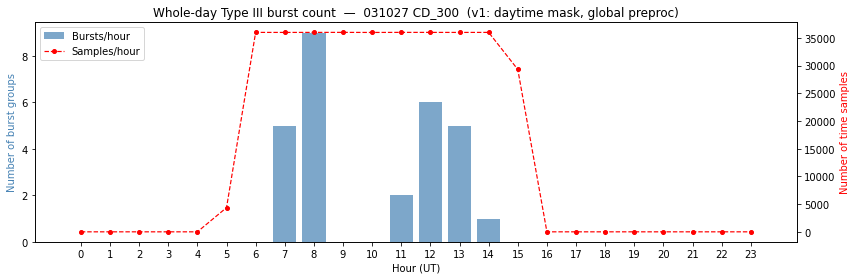

In [8]:
# ── Results ───────────────────────────────────────────────────────────────────
print("\nBursts per hour   :", bursts_per_hour)
print("Samples per hour  :", len_mask_per_hour)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(range(24), bursts_per_hour, color='steelblue', alpha=0.7, label='Bursts/hour')
ax2.plot(range(24), len_mask_per_hour, 'r--o', ms=4, lw=1.2, label='Samples/hour')

ax1.set_xlabel('Hour (UT)')
ax1.set_ylabel('Number of burst groups', color='steelblue')
ax2.set_ylabel('Number of time samples', color='red')
ax1.set_xticks(range(24))
ax1.set_title('Whole-day Type III burst count  —  031027 CD_300  (v1: daytime mask, global preproc)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()